In [1]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.11.0


In [2]:
video_path = "subject1/vid.avi"

print(video_path)

subject1/vid.avi


In [3]:
cap_ubfc = cv2.VideoCapture(video_path)

fps = cap_ubfc.get(cv2.CAP_PROP_FPS)
frame_count = int(cap_ubfc.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap_ubfc.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap_ubfc.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("FPS:", fps)
print("Frames:", frame_count)
print("Resolution:", width, "x", height)
print("Duration:", duration, "seconds")

cap_ubfc.release()

FPS: 29.264106
Frames: 1547
Resolution: 640 x 480
Duration: 52.863395177696525 seconds


In [4]:
ppg_path = "subject1/ground_truth.txt"

with open(ppg_path, "r") as f:
    lines = f.readlines()

print("Number of lines:", len(lines))
print("First 5 lines:")

for line in lines[:5]:
    print(line.strip())

Number of lines: 3
First 5 lines:
1.2028675e-01   7.7360657e-01   1.4119226e+00   1.5395677e+00   1.3443377e+00   1.1340589e+00   7.8861039e-01   6.3843695e-01   1.6214427e-01  -1.7258076e-01  -3.6781074e-01  -5.8935374e-01  -7.4930446e-01  -9.4755323e-01  -1.1638246e+00  -1.3440508e+00  -1.4071299e+00  -1.5332882e+00  -1.6481824e+00  -1.6481824e+00  -1.6481824e+00  -1.6481824e+00  -1.4454280e+00  -3.5280691e-01   4.5821079e-01   7.9293582e-01   6.4744826e-01   3.6809771e-01   2.3292810e-01  -3.7411138e-02  -2.7021828e-01  -4.2791616e-01  -4.4291999e-01  -4.4291999e-01  -7.1325923e-01  -8.9348538e-01  -1.1788284e+00  -1.2989942e+00  -1.3102584e+00  -1.4521865e+00  -1.6256541e+00  -1.6143900e+00  -1.3440508e+00  -1.8010520e-01   9.0877618e-01   1.4043981e+00   1.1881267e+00   9.0877618e-01   5.2259659e-01   9.7758480e-02  -3.4636383e-01  -6.3441028e-01  -6.6820269e-01  -7.1325923e-01  -8.2590057e-01  -9.9112290e-01  -1.1187681e+00  -1.1187681e+00  -1.1638246e+00  -1.2914698e+00  -1.4566

In [5]:
import numpy as np

ground_truth = np.loadtxt(ppg_path)

print("Ground truth shape:", ground_truth.shape)

print("BVP samples:", len(ground_truth[0]))
print("HR samples:", len(ground_truth[1]))
print("Timestamp samples:", len(ground_truth[2]))

print("\nFirst 5 BVP:", ground_truth[0][:5])
print("First 5 HR:", ground_truth[1][:5])
print("First 5 timestamps:", ground_truth[2][:5])

print("\nLast 5 timestamps:", ground_truth[2][-5:])

Ground truth shape: (3, 1547)
BVP samples: 1547
HR samples: 1547
Timestamp samples: 1547

First 5 BVP: [0.12028675 0.77360657 1.4119226  1.5395677  1.3443377 ]
First 5 HR: [97. 97. 97. 97. 97.]
First 5 timestamps: [0.    0.011 0.055 0.067 0.109]

Last 5 timestamps: [52.525 52.567 52.608 52.649 52.691]


In [6]:
timestamps = ground_truth[2]

intervals = np.diff(timestamps)

print("Average interval:", np.mean(intervals))
print("Minimum interval:", np.min(intervals))
print("Maximum interval:", np.max(intervals))

estimated_fs = 1 / np.mean(intervals)

print("Estimated BVP sampling rate:", estimated_fs, "Hz")

Average interval: 0.034082147477360936
Minimum interval: 0.0
Maximum interval: 0.22300000000000253
Estimated BVP sampling rate: 29.340874153081167 Hz


In [7]:
zero_intervals = np.sum(intervals == 0)

print("Duplicate timestamps:", zero_intervals)
print("Total intervals:", len(intervals))

print("Median interval:", np.median(intervals))
print("Mean interval excluding zeros:",
      np.mean(intervals[intervals > 0]))

Duplicate timestamps: 1
Total intervals: 1546
Median interval: 0.03799999999999848
Mean interval excluding zeros: 0.0341042071197411


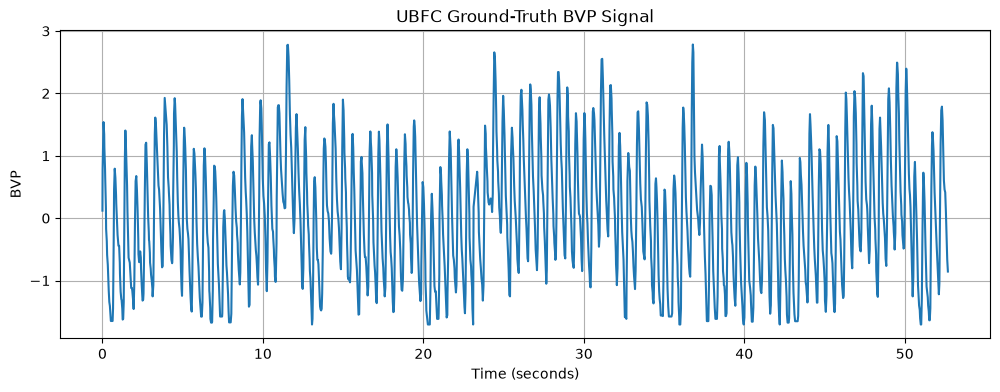

In [9]:
import matplotlib.pyplot as plt

bvp = ground_truth[0]
timestamps = ground_truth[2]

plt.figure(figsize=(12, 4))
plt.plot(timestamps, bvp)
plt.xlabel("Time (seconds)")
plt.ylabel("BVP")
plt.title("UBFC Ground-Truth BVP Signal")
plt.grid(True)
plt.show()

In [10]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

# Remove mean
bvp_centered = bvp - np.mean(bvp)

# Estimate sampling rate from the video
fs = fps

# FFT
n = len(bvp_centered)
freqs = np.fft.rfftfreq(n, d=1/fs)
fft_mag = np.abs(np.fft.rfft(bvp_centered))

# Keep physiological heart-rate range: 0.7–4 Hz
mask = (freqs >= 0.7) & (freqs <= 4.0)

dominant_freq = freqs[mask][np.argmax(fft_mag[mask])]
heart_rate = dominant_freq * 60

print("Dominant frequency:", dominant_freq, "Hz")
print("Estimated heart rate:", heart_rate, "BPM")

Dominant frequency: 1.7970847252747253 Hz
Estimated heart rate: 107.82508351648352 BPM


In [11]:
cap_ubfc = cv2.VideoCapture(video_path)

cap_ubfc.set(cv2.CAP_PROP_POS_FRAMES, 500)

ret, frame = cap_ubfc.read()

cap_ubfc.release()

print("Frame successfully read:", ret)
print("Frame shape:", frame.shape)

Frame successfully read: True
Frame shape: (480, 640, 3)


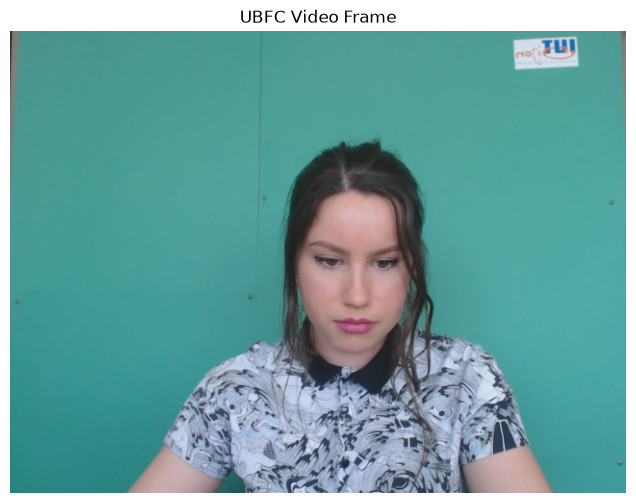

In [12]:
import matplotlib.pyplot as plt

# OpenCV uses BGR, matplotlib expects RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("UBFC Video Frame")
plt.show()

In [12]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(100, 100)
)

print("Faces detected:", len(faces))

for (x, y, w, h) in faces:
    print("Face bounding box:")
    print("x:", x, "y:", y, "width:", w, "height:", h)

Faces detected: 2
Face bounding box:
x: 285 y: 185 width: 147 height: 147
Face bounding box:
x: 271 y: 306 width: 151 height: 151


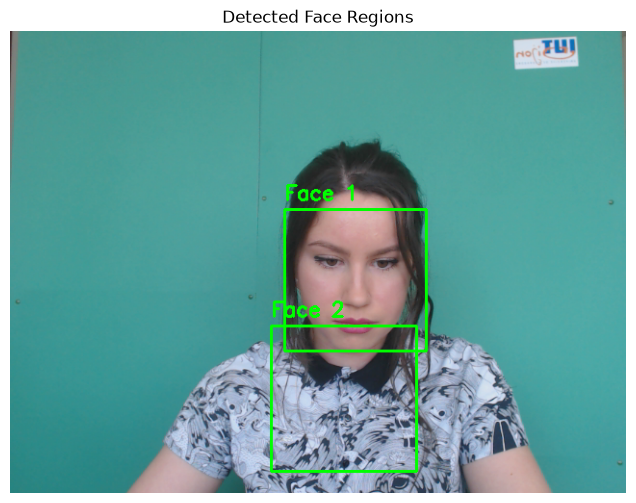

In [14]:
frame_boxes = frame.copy()

for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(
        frame_boxes,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        frame_boxes,
        f"Face {i+1}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

frame_boxes_rgb = cv2.cvtColor(frame_boxes, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(frame_boxes_rgb)
plt.axis("off")
plt.title("Detected Face Regions")
plt.show()

In [13]:
frame_h, frame_w = frame.shape[:2]

frame_center = np.array([frame_w / 2, frame_h / 2])

best_face = None
best_distance = float("inf")

for (x, y, w, h) in faces:
    face_center = np.array([x + w / 2, y + h / 2])

    distance = np.linalg.norm(face_center - frame_center)

    if distance < best_distance:
        best_distance = distance
        best_face = (x, y, w, h)

print("Selected face:", best_face)

Selected face: (np.int32(285), np.int32(185), np.int32(147), np.int32(147))


Face crop shape: (147, 147, 3)


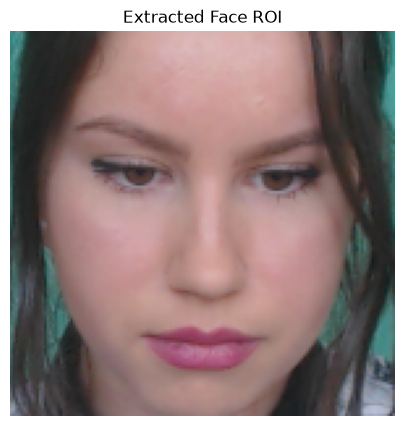

In [14]:
x, y, w, h = best_face

face_crop = frame[y:y+h, x:x+w]

print("Face crop shape:", face_crop.shape)
face_crop_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(face_crop_rgb)
plt.axis("off")
plt.title("Extracted Face ROI")
plt.show()

In [15]:
# Read 10 consecutive frames and extract the face ROI

cap_ubfc = cv2.VideoCapture(video_path)

face_frames = []

for i in range(10):
    ret, frame_i = cap_ubfc.read()

    if not ret:
        print("Could not read frame:", i)
        break

    gray_i = cv2.cvtColor(frame_i, cv2.COLOR_BGR2GRAY)

    faces_i = face_cascade.detectMultiScale(
        gray_i,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(100, 100)
    )

    if len(faces_i) == 0:
        print("No face detected in frame:", i)
        continue

    # Select the face closest to the center
    h_i, w_i = frame_i.shape[:2]
    center_i = np.array([w_i / 2, h_i / 2])

    best_face_i = min(
        faces_i,
        key=lambda f: np.linalg.norm(
            np.array([f[0] + f[2]/2, f[1] + f[3]/2]) - center_i
        )
    )

    x_i, y_i, w_face_i, h_face_i = best_face_i

    # Crop face
    crop_i = frame_i[
        y_i:y_i+h_face_i,
        x_i:x_i+w_face_i
    ]

    # Resize to fixed size
    crop_i = cv2.resize(crop_i, (64, 64))

    face_frames.append(crop_i)

cap_ubfc.release()

face_frames = np.array(face_frames)

print("Number of face frames:", len(face_frames))
print("Face tensor shape:", face_frames.shape)

Number of face frames: 10
Face tensor shape: (10, 64, 64, 3)


In [16]:
# Reference face from frame 500
x_ref, y_ref, w_ref, h_ref = best_face

# Center of the reference face
cx = x_ref + w_ref // 2
cy = y_ref + h_ref // 2

print("Reference face center:", (cx, cy))
print("Reference face size:", (w_ref, h_ref))

Reference face center: (np.int32(358), np.int32(258))
Reference face size: (np.int32(147), np.int32(147))


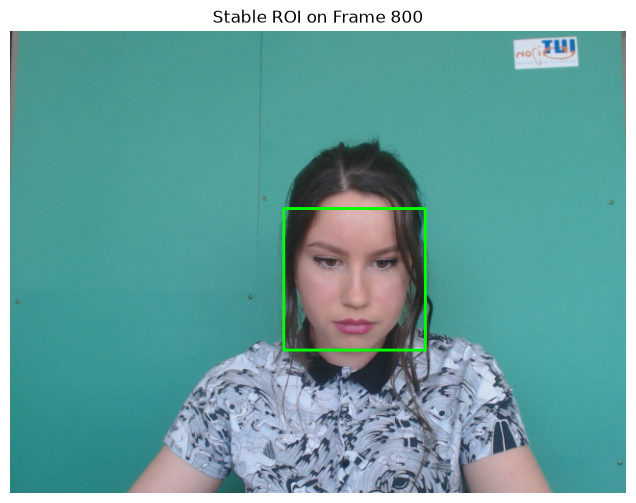

In [17]:
# Read a different frame
cap_ubfc = cv2.VideoCapture(video_path)
cap_ubfc.set(cv2.CAP_PROP_POS_FRAMES, 800)

ret, test_frame = cap_ubfc.read()
cap_ubfc.release()

# Draw the reference ROI
x1 = int(cx - w_ref / 2)
y1 = int(cy - h_ref / 2)
x2 = int(cx + w_ref / 2)
y2 = int(cy + h_ref / 2)

test_frame_box = test_frame.copy()

cv2.rectangle(
    test_frame_box,
    (x1, y1),
    (x2, y2),
    (0, 255, 0),
    2
)

test_frame_rgb = cv2.cvtColor(test_frame_box, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(test_frame_rgb)
plt.axis("off")
plt.title("Stable ROI on Frame 800")
plt.show()

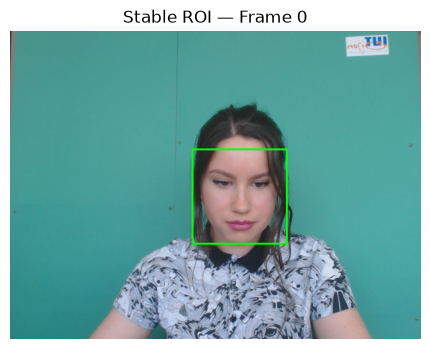

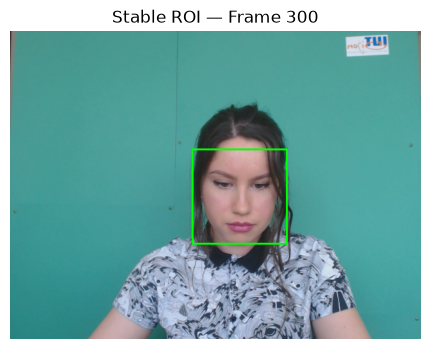

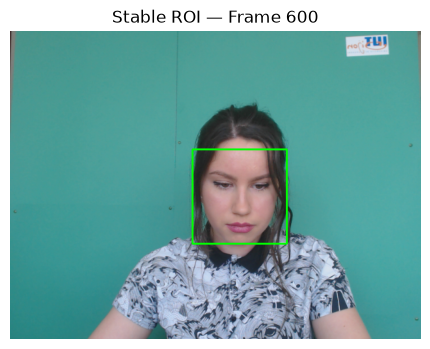

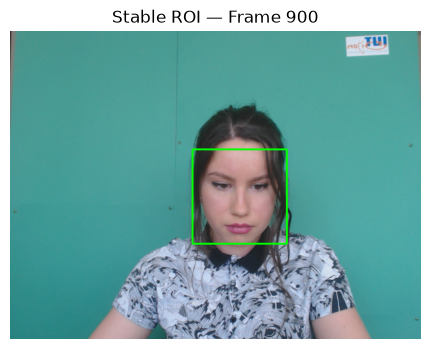

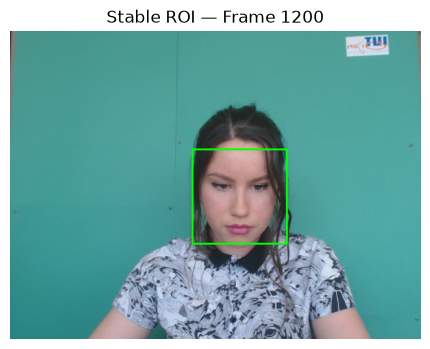

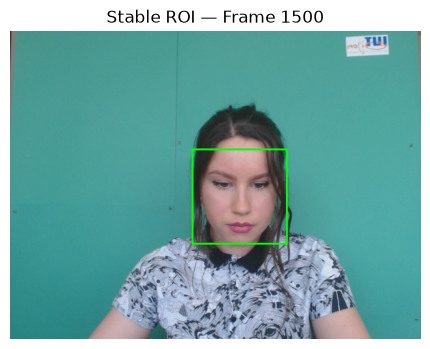

In [18]:
frame_numbers = [0, 300, 600, 900, 1200, 1500]

cap_ubfc = cv2.VideoCapture(video_path)

for frame_num in frame_numbers:
    cap_ubfc.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, test_frame = cap_ubfc.read()

    if not ret:
        print("Could not read frame:", frame_num)
        continue

    # Same fixed ROI
    x1 = int(cx - w_ref / 2)
    y1 = int(cy - h_ref / 2)
    x2 = int(cx + w_ref / 2)
    y2 = int(cy + h_ref / 2)

    cv2.rectangle(
        test_frame,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    test_frame_rgb = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 4))
    plt.imshow(test_frame_rgb)
    plt.title(f"Stable ROI — Frame {frame_num}")
    plt.axis("off")
    plt.show()

cap_ubfc.release()

In [19]:
cap_ubfc = cv2.VideoCapture(video_path)

all_face_frames = []

x1 = int(cx - w_ref / 2)
y1 = int(cy - h_ref / 2)
x2 = int(cx + w_ref / 2)
y2 = int(cy + h_ref / 2)

while True:
    ret, frame_i = cap_ubfc.read()

    if not ret:
        break

    # Crop stable face ROI
    face = frame_i[y1:y2, x1:x2]

    # Resize
    face = cv2.resize(face, (64, 64))

    all_face_frames.append(face)

cap_ubfc.release()

all_face_frames = np.array(all_face_frames)

print("Extracted frames:", len(all_face_frames))
print("Shape:", all_face_frames.shape)

Extracted frames: 1547
Shape: (1547, 64, 64, 3)


In [20]:
all_face_frames_rgb = all_face_frames[:, :, :, ::-1]

print("RGB tensor shape:", all_face_frames_rgb.shape)

RGB tensor shape: (1547, 64, 64, 3)


In [21]:
all_face_frames_normalized = all_face_frames_rgb.astype(np.float32) / 255.0

print("Shape:", all_face_frames_normalized.shape)
print("Minimum:", all_face_frames_normalized.min())
print("Maximum:", all_face_frames_normalized.max())

Shape: (1547, 64, 64, 3)
Minimum: 0.05490196
Maximum: 0.8745098


In [22]:
window_size = 150

video_sample = all_face_frames_normalized[:window_size]
bvp_sample = bvp[:window_size]

print("Video sample shape:", video_sample.shape)
print("BVP sample shape:", bvp_sample.shape)

Video sample shape: (150, 64, 64, 3)
BVP sample shape: (150,)


In [23]:
video_duration = 150 / fps

bvp_duration = timestamps[149] - timestamps[0]

print("Video window duration:", video_duration, "seconds")
print("BVP window duration:", bvp_duration, "seconds")
print("BVP start time:", timestamps[0])
print("BVP end time:", timestamps[149])

Video window duration: 5.1257332105070965 seconds
BVP window duration: 4.892 seconds
BVP start time: 0.0
BVP end time: 4.892


In [24]:
window_size = 150
stride = 75

video_windows = []
bvp_windows = []

for start in range(0, len(all_face_frames_normalized) - window_size + 1, stride):
    end = start + window_size

    video_windows.append(
        all_face_frames_normalized[start:end]
    )

    bvp_windows.append(
        bvp[start:end]
    )

video_windows = np.array(video_windows)
bvp_windows = np.array(bvp_windows)

print("Video windows shape:", video_windows.shape)
print("BVP windows shape:", bvp_windows.shape)

Video windows shape: (19, 150, 64, 64, 3)
BVP windows shape: (19, 150)


In [25]:
video_windows_torch = np.transpose(
    video_windows,
    (0, 4, 1, 2, 3)
)

print("PyTorch video shape:", video_windows_torch.shape)
print("BVP shape:", bvp_windows.shape)

PyTorch video shape: (19, 3, 150, 64, 64)
BVP shape: (19, 150)


In [26]:
import torch
import torch.nn as nn

conv3d = nn.Conv3d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    padding=1
)

# Convert our NumPy data to a PyTorch tensor
x = torch.tensor(video_windows_torch, dtype=torch.float32)

print("Input shape:", x.shape)

# Pass through Conv3D
y = conv3d(x)

print("Output shape:", y.shape)

Input shape: torch.Size([19, 3, 150, 64, 64])
Output shape: torch.Size([19, 16, 150, 64, 64])


In [27]:
relu = nn.ReLU()

y_relu = relu(y)

print("Before ReLU:")
print("Min:", y.min().item())
print("Max:", y.max().item())

print("\nAfter ReLU:")
print("Min:", y_relu.min().item())
print("Max:", y_relu.max().item())
print("Shape:", y_relu.shape)

Before ReLU:
Min: -0.871911883354187
Max: 1.0639183521270752

After ReLU:
Min: 0.0
Max: 1.0639183521270752
Shape: torch.Size([19, 16, 150, 64, 64])


In [28]:
pool = nn.MaxPool3d(
    kernel_size=(1, 2, 2),
    stride=(1, 2, 2)
)

y_pool = pool(y_relu)

print("Before pooling:", y_relu.shape)
print("After pooling:", y_pool.shape)

Before pooling: torch.Size([19, 16, 150, 64, 64])
After pooling: torch.Size([19, 16, 150, 32, 32])


In [29]:
conv3d_2 = nn.Conv3d(
    in_channels=16,
    out_channels=32,
    kernel_size=3,
    padding=1
)

y2 = conv3d_2(y_pool)

print("Before Conv3D:", y_pool.shape)
print("After Conv3D:", y2.shape)

Before Conv3D: torch.Size([19, 16, 150, 32, 32])
After Conv3D: torch.Size([19, 32, 150, 32, 32])


In [30]:
y2_relu = nn.ReLU()(y2)

print("Before ReLU:")
print("Min:", y2.min().item())
print("Max:", y2.max().item())

print("\nAfter ReLU:")
print("Min:", y2_relu.min().item())
print("Max:", y2_relu.max().item())
print("Shape:", y2_relu.shape)

Before ReLU:
Min: -0.5515656471252441
Max: 0.6614179611206055

After ReLU:
Min: 0.0
Max: 0.6614179611206055
Shape: torch.Size([19, 32, 150, 32, 32])


In [31]:
pool2 = nn.MaxPool3d(
    kernel_size=(1, 2, 2),
    stride=(1, 2, 2)
)

y2_pool = pool2(y2_relu)

print("Before pooling:", y2_relu.shape)
print("After pooling:", y2_pool.shape)

Before pooling: torch.Size([19, 32, 150, 32, 32])
After pooling: torch.Size([19, 32, 150, 16, 16])


In [32]:
spatial_pool = nn.AdaptiveAvgPool3d((150, 1, 1))

y_spatial = spatial_pool(y2_pool)

print("Before spatial pooling:", y2_pool.shape)
print("After spatial pooling:", y_spatial.shape)

Before spatial pooling: torch.Size([19, 32, 150, 16, 16])
After spatial pooling: torch.Size([19, 32, 150, 1, 1])


In [33]:
y_temporal = y_spatial.squeeze(-1).squeeze(-1)

print("After removing spatial dimensions:", y_temporal.shape)

After removing spatial dimensions: torch.Size([19, 32, 150])


In [34]:
y_temporal = y_temporal.permute(0, 2, 1)

print("Temporal feature shape:", y_temporal.shape)

Temporal feature shape: torch.Size([19, 150, 32])


In [35]:
output_layer = nn.Linear(32, 1)

bvp_pred = output_layer(y_temporal)

print("Predicted BVP shape:", bvp_pred.shape)

Predicted BVP shape: torch.Size([19, 150, 1])


In [36]:
bvp_pred = bvp_pred.squeeze(-1)

print("Final BVP shape:", bvp_pred.shape)

Final BVP shape: torch.Size([19, 150])


In [37]:
criterion = nn.MSELoss()

loss = criterion(
    bvp_pred,
    torch.tensor(bvp_windows, dtype=torch.float32)
)

print("Initial MSE loss:", loss.item())

Initial MSE loss: 1.049729347229004


In [38]:
class TinyRPPGNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv3d(
            3, 16,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool3d(
            kernel_size=(1, 2, 2),
            stride=(1, 2, 2)
        )

        self.conv2 = nn.Conv3d(
            16, 32,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool3d(
            kernel_size=(1, 2, 2),
            stride=(1, 2, 2)
        )

        self.spatial_pool = nn.AdaptiveAvgPool3d(
            (150, 1, 1)
        )

        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.spatial_pool(x)

        x = x.squeeze(-1).squeeze(-1)

        # (N, 32, 150) → (N, 150, 32)
        x = x.permute(0, 2, 1)

        # (N, 150, 32) → (N, 150, 1)
        x = self.output_layer(x)

        # (N, 150, 1) → (N, 150)
        x = x.squeeze(-1)

        return x

In [39]:
model = TinyRPPGNet()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

TinyRPPGNet(
  (conv1): Conv3d(3, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (relu1): ReLU()
  (pool1): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (relu2): ReLU()
  (pool2): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (spatial_pool): AdaptiveAvgPool3d(output_size=(150, 1, 1))
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [40]:
model.eval()

with torch.no_grad():
    test_prediction = model(x)

print("Input shape:", x.shape)
print("Prediction shape:", test_prediction.shape)
print("Prediction min:", test_prediction.min().item())
print("Prediction max:", test_prediction.max().item())

Input shape: torch.Size([19, 3, 150, 64, 64])
Prediction shape: torch.Size([19, 150])
Prediction min: -0.011128511279821396
Prediction max: 0.01955224573612213


In [41]:
y_target = torch.tensor(
    bvp_windows,
    dtype=torch.float32
)

print("Input:", x.shape)
print("Target:", y_target.shape)

Input: torch.Size([19, 3, 150, 64, 64])
Target: torch.Size([19, 150])


In [42]:
model.train()

optimizer.zero_grad()

# Forward pass
prediction = model(x)

# Calculate error
loss = criterion(prediction, y_target)

# Backpropagation
loss.backward()

# Update weights
optimizer.step()

print("Training loss:", loss.item())

Training loss: 1.0498703718185425


In [43]:
num_epochs = 50

for epoch in range(num_epochs):

    model.train()

    optimizer.zero_grad()

    prediction = model(x)

    loss = criterion(prediction, y_target)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {loss.item():.6f}")

Epoch  5 | Loss: 1.049625
Epoch 10 | Loss: 1.049390
Epoch 15 | Loss: 1.049226
Epoch 20 | Loss: 1.049094
Epoch 25 | Loss: 1.048902
Epoch 30 | Loss: 1.048720
Epoch 35 | Loss: 1.048517
Epoch 40 | Loss: 1.048436
Epoch 45 | Loss: 1.048133
Epoch 50 | Loss: 1.047990


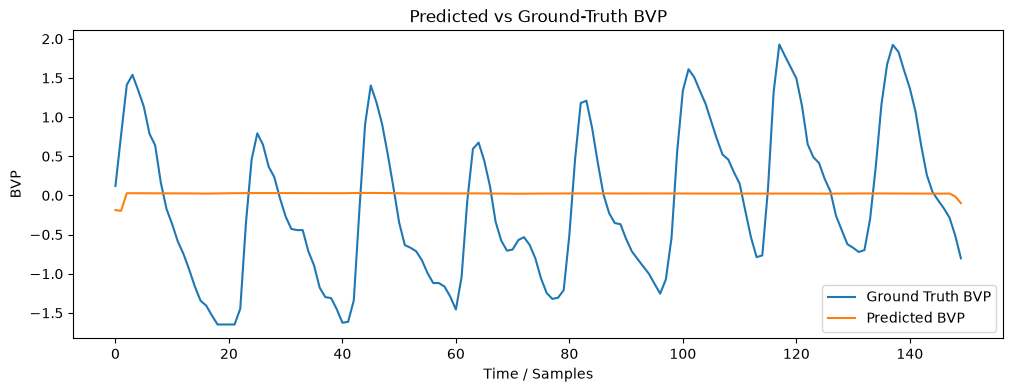

In [44]:
model.eval()

with torch.no_grad():
    prediction = model(x)

predicted_bvp = prediction[0].numpy()
true_bvp = bvp_windows[0]

plt.figure(figsize=(12, 4))

plt.plot(true_bvp, label="Ground Truth BVP")
plt.plot(predicted_bvp, label="Predicted BVP")

plt.xlabel("Time / Samples")
plt.ylabel("BVP")
plt.title("Predicted vs Ground-Truth BVP")
plt.legend()
plt.show()

In [3]:
import os

dataset_path = r"D:\projects\RPPG\DATASET_2"

subjects = []

for name in os.listdir(dataset_path):
    if name.lower().startswith("subject"):
        full_path = os.path.join(dataset_path, name)

        if os.path.isdir(full_path):
            subjects.append(name)

subjects.sort(key=lambda x: int(x.replace("subject", "")))

print("Number of subjects:", len(subjects))
print("Subjects:")
for subject in subjects:
    print(subject)

Number of subjects: 42
Subjects:
subject1
subject3
subject4
subject5
subject8
subject9
subject10
subject11
subject12
subject13
subject14
subject15
subject16
subject17
subject18
subject20
subject22
subject23
subject24
subject25
subject26
subject27
subject30
subject31
subject32
subject33
subject34
subject35
subject36
subject37
subject38
subject39
subject40
subject41
subject42
subject43
subject44
subject45
subject46
subject47
subject48
subject49


In [5]:
import os

dataset_path = r"D:\projects\RPPG\DATASET_2"

subjects = [
    x for x in os.listdir(dataset_path)
    if x.startswith("subject")
    and os.path.isdir(os.path.join(dataset_path, x))
]

complete = []
missing_video = []
missing_gt = []

for subject in subjects:
    path = os.path.join(dataset_path, subject)

    video = os.path.exists(os.path.join(path, "vid.avi"))
    gt = os.path.exists(os.path.join(path, "ground_truth.txt"))

    if video and gt:
        complete.append(subject)
    elif not video:
        missing_video.append(subject)
    elif not gt:
        missing_gt.append(subject)

print("Total subjects:", len(subjects))
print("Complete:", len(complete))
print("Missing video:", len(missing_video))
print("Missing ground truth:", len(missing_gt))

Total subjects: 42
Complete: 42
Missing video: 0
Missing ground truth: 0
